# Ground State Energy of the Ising Model

## Data Loading \& Imports

In [1]:
chain_file = "data/1D/ising_chain_8.txt"
small_nearest_file = "data/2D/4x4_EA.txt"
nearest_neighbor_file = "data/2D/10x10_EA.txt"

In [2]:
import os
import json
import numpy as np
import networkx as nx
from natsort import natsorted
import gurobipy as gp
from math import sqrt
import matplotlib.pyplot as plt

In [3]:
import numpy as np
import matplotlib
from scipy.optimize import minimize
from qiskit import QuantumCircuit, circuit
from qiskit_aer import AerSimulator
import qiskit_nature.second_q as sq
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_algorithms.optimizers import SPSA

from qiskit.quantum_info import Statevector, SparsePauliOp
from qiskit.visualization import plot_histogram

from qiskit.circuit.library import QAOAAnsatz
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

In [4]:
# Backend and transpiler setup
service = QiskitRuntimeService(name="mane4960-dedicated")

qpu = service.backend("ibm_rensselaer")
sim = AerSimulator()
qpu_sim = AerSimulator.from_backend(qpu)

pm = generate_preset_pass_manager(backend=qpu_sim, optimization_level=3)

## Function Definitions

In [5]:
"""
Data Loading Helper Function
"""
def read_nxgraph(filename):
    """
    Reads a graph from a file in a specified text format.
    """
    graph = nx.Graph()
    with open(filename, 'r') as file:
        line = file.readline()
        is_first_line = True
        while line is not None and line != '':
            if '//' not in line:
                if is_first_line:
                    strings = line.split(" ")
                    num_nodes = int(strings[0])
                    nodes = list(range(num_nodes))
                    graph.add_nodes_from(nodes)
                    is_first_line = False
                else:
                    node1, node2, weight_str = line.split()
                    # Edge weight coupling J_ij
                    graph.add_edge(int(node1) - 1, int(node2) - 1, weight=float(weight_str))
            line = file.readline()
    return graph

In [6]:
"""
Visual Helper Functions
"""
def lattice_layout(graph, rows, cols):
    """
    Return the positions of each node in a lattice shape
    """
    pos = {}
    for i, node in enumerate(graph.nodes):
        row = i // cols
        col = i % cols
        pos[node] = (col, -row)
    return pos

def draw_graph(graph, rows, cols):
    """
    Draws the graph using the lattice format
    """
    pos = lattice_layout(graph, rows, cols)
    plt.figure(figsize=(8, 6))

    nx.draw(graph, pos, with_labels=True, node_size=5, node_color='lightblue', font_size=8)
    plt.show()

In [7]:
"""
Gurobi Helper Function
"""
def gurobi_ising_solver(graph):
    """
    Initializes Gurobi solver with Hamiltonian objective and minimizes it
    """
    # Create QUBO matrix
    nodes = len(list(graph.nodes))
    J = nx.to_numpy_array(graph)

    # Construct gurobi model
    model = gp.Model("ising_solver")

    # Set time limit 1 hr
    model.setParam('TimeLimit', 3600)
    
    # Set to MIP
    model.setParam("MIPGap", 0.0)

    # Create variable for each vertex
    x = model.addVars(nodes, vtype=gp.GRB.BINARY)

    # Hamiltonian/objective calculation (2*x-1 to convert to spin +1,-1 not binary 0,1)
    objective = gp.quicksum(
        -J[i, j] * (2 * x[i] - 1) * (2 * x[j] - 1)
        for i in range(nodes) for j in range(i+1, nodes) if J[i, j] != 0.0
    )
    model.setObjective(objective, gp.GRB.MINIMIZE)
    
    # Solve
    model.optimize()
    obj_val = model.ObjVal
    obj_bnd = model.ObjBound
    solution = ""
    for i in range(nodes):
        solution += f"{int(x[i].X)}"

    return obj_val, solution

In [8]:
"""
Qiskit Helper Functions
"""
def build_paulis(graph):
    """
    Constructs Ising Hamiltonian in the quantum circuit, replacing spins with Pauli Z: 
    -Σ J_ij * x_i * x_j --> -Σ J_ij * (Z_i ⊗ Z_j)
    """
    pauli_list = []
    for edge in list(graph.edges()):
        weight_list = graph.get_edge_data(edge[0], edge[1])
        pauli_list.append(("ZZ", [edge[0], edge[1]], -weight_list['weight']))
    return pauli_list

def build_ansatz(cost_hamiltonian, reps):
    """
    Creates the ansatz for QAOA using Qiskit's built-in function
    """
    ansatz = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=reps)
    ansatz.measure_all()
    return ansatz

def cost_func(params, ansatz, hamiltonian, estimator):
    """
    Cost function to minimize the circuit hamiltonian for SciPy
    """
    isa_hamiltonian = hamiltonian.apply_layout(ansatz.layout)

    pub = (ansatz, isa_hamiltonian, params)
    job = estimator.run([pub])

    results = job.result()[0]
    cost = results.data.evs

    objective_func_vals.append(cost)

    return cost

def spsa_cost_wrapper(params):
    """
    For use with Qiskit Algorithms SPSA optimizer
    """
    return cost_func(params, candidate_circuit, cost_hamiltonian, estimator)

def calculate_energy(bitstring, graph):
    """
    Recalculate energy given the Qiskit solution to compare with classical/ground truth energy
    """
    energy = 0

    # Calculate Hamiltonian
    for node1, node2, data in graph.edges(data=True):
        # Convert binary to spin (0 --> 1, 1 --> -1)
        s1 = 1 if bitstring[node1] == '0' else -1
        s2 = 1 if bitstring[node2] == '0' else -1
        
        energy += -data['weight'] * (s1 * s2)
        
    return energy

# 1. Initial 2x2 Example

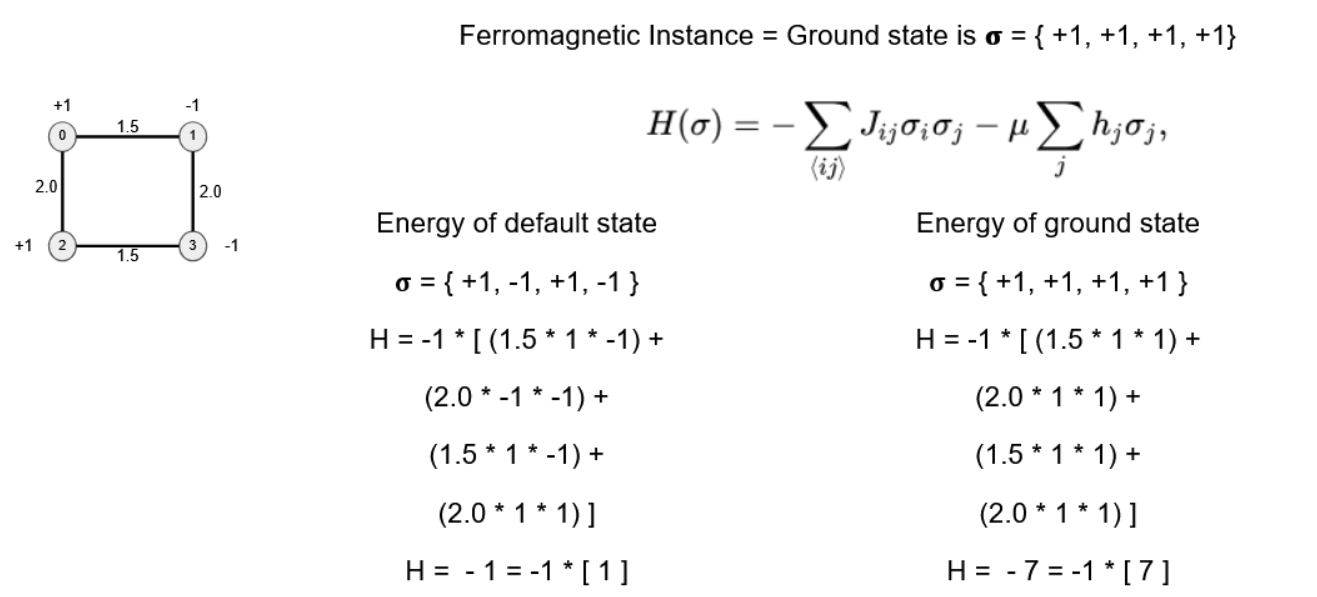

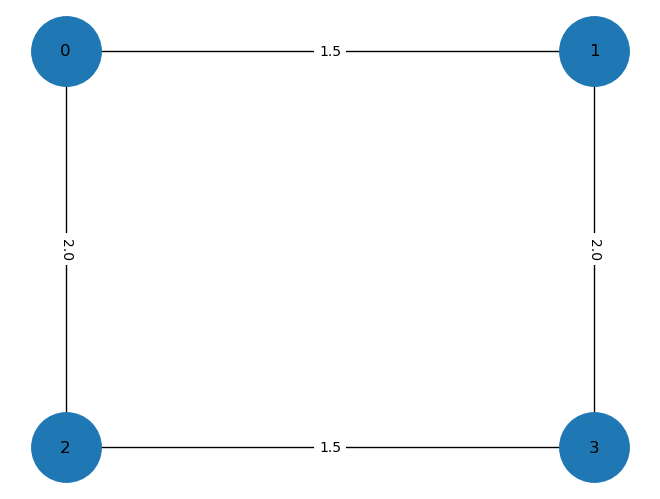

In [9]:
G = nx.Graph()
G.add_node(0, pos=(0,0))
G.add_node(1, pos=(1,0))
G.add_node(2, pos=(0,-1))
G.add_node(3, pos=(1,-1))
G.add_edge(0, 1, weight=1.5)
G.add_edge(1, 3, weight=2.0)
G.add_edge(0, 2, weight=2.0)
G.add_edge(2, 3, weight=1.5)

pos=nx.get_node_attributes(G,'pos')
nx.draw(G, pos, node_size=2500, with_labels='True')
labels = nx.get_edge_attributes(G,'weight')
nx.draw_networkx_edge_labels(G,pos,edge_labels=labels)
plt.show()

In [10]:
initial_paulis = build_paulis(G)
cost_hamiltonian = SparsePauliOp.from_sparse_list(initial_paulis, 4)
print(cost_hamiltonian)

SparsePauliOp(['IIZZ', 'IZIZ', 'ZIZI', 'ZZII'],
              coeffs=[-1.5+0.j, -2. +0.j, -2. +0.j, -1.5+0.j])


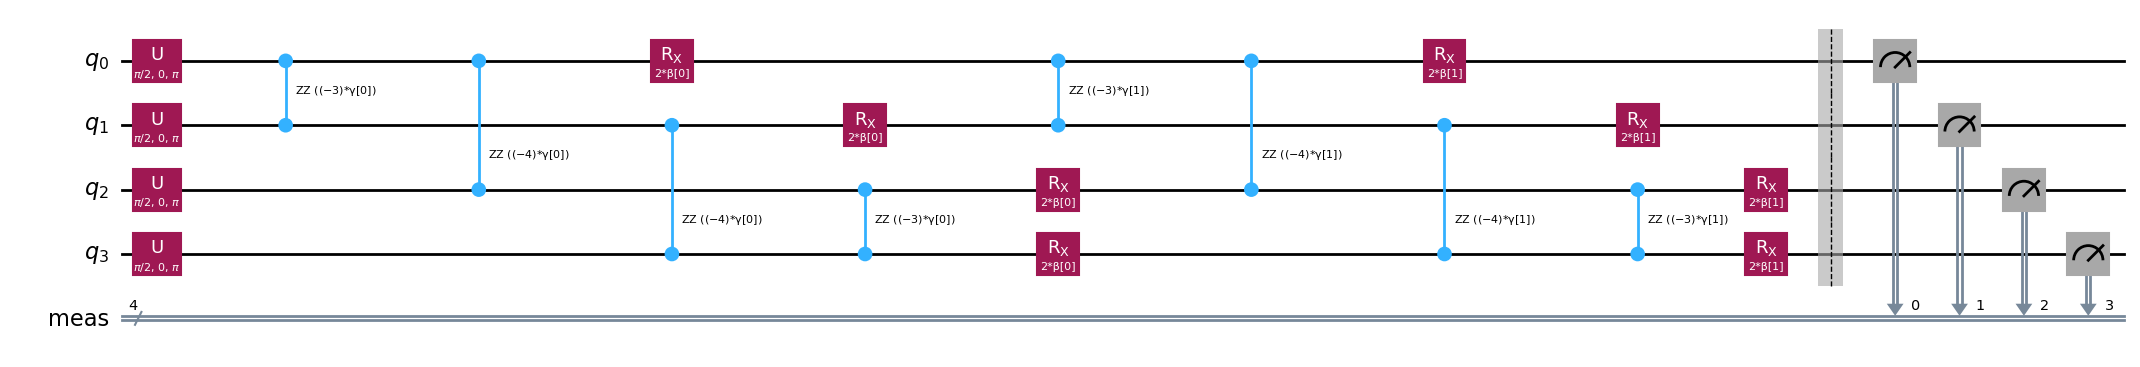

In [11]:
ansatz = build_ansatz(cost_hamiltonian, reps=2)
ansatz.decompose().decompose().draw(output="mpl", fold=False, idle_wires=False, scale=1)

In [13]:
candidate_circuit = pm.run(ansatz)
initial_gamma = 1.0
initial_beta = 0.5
init_params = [initial_beta, initial_beta, initial_gamma, initial_gamma]

objective_func_vals = []
with Session(backend=qpu) as session:
    estimator = Estimator(mode=session)

    estimator.options.default_shots = 1000

    estimator.options.dynamical_decoupling.enable = True
    estimator.options.dynamical_decoupling.sequence_type = "XY4"
    estimator.options.twirling.enable_gates = True
    estimator.options.twirling.num_randomizations = "auto"

    estimator.options.resilience.zne_mitigation = True
    estimator.options.resilience.zne.noise_factors = (1, 3, 5)
    estimator.options.resilience.zne.extrapolator = ("exponential", "linear")

    optimizer = SPSA(maxiter=100)
    
    result = optimizer.minimize(
        fun=spsa_cost_wrapper,
        x0=init_params
    )
    print(result)

{   'fun': array(1.23234364),
    'jac': None,
    'nfev': 200,
    'nit': 100,
    'njev': None,
    'x': array([-1.70227215,  1.15087175,  1.68975181,  0.02300095])}


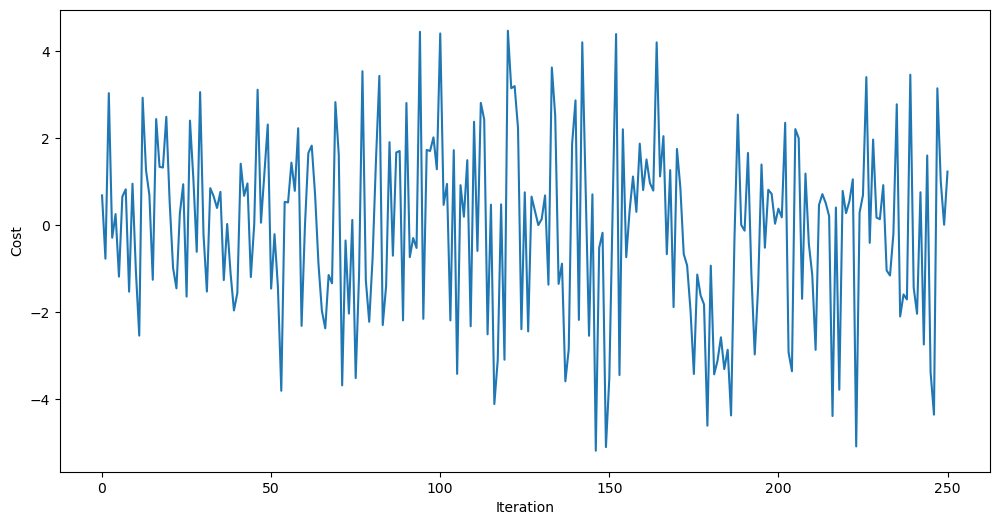

In [14]:
plt.figure(figsize=(12, 6))
plt.plot(objective_func_vals)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

In [15]:
optimized_circuit = candidate_circuit.assign_parameters(result.x)
sampler = Sampler(mode=sim)

sampler.options.default_shots = 100000

# Set simple error suppression/mitigation options
sampler.options.dynamical_decoupling.enable = True
sampler.options.dynamical_decoupling.sequence_type = "XY4"
sampler.options.twirling.enable_gates = True
sampler.options.twirling.num_randomizations = "auto"

pub = (optimized_circuit)
job = sampler.run([pub], shots=int(1e5))
counts_int = job.result()[0].data.meas.get_int_counts()
counts_bin = job.result()[0].data.meas.get_counts()

D:\Anaconda\envs\Gurobi\Lib\site-packages\qiskit_ibm_runtime\fake_provider\local_service.py:273: UserWarning: Options {'dynamical_decoupling': {'enable': True, 'sequence_type': 'XY4'}, 'twirling': {'enable_gates': True, 'num_randomizations': 'auto'}} have no effect in local testing mode.
  warnings.warn(f"Options {options_copy} have no effect in local testing mode.")


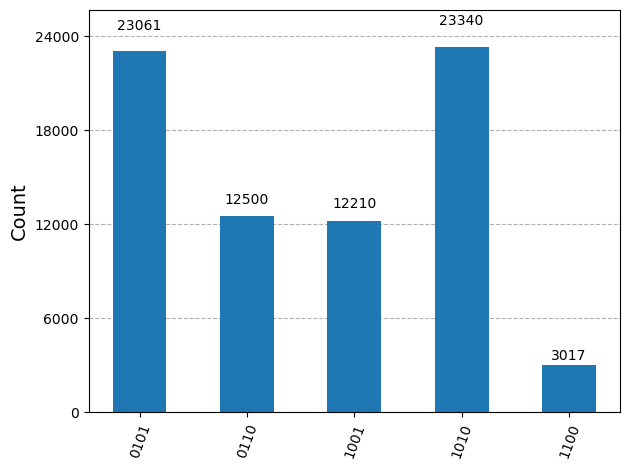

In [16]:
top_5 = dict(sorted(counts_bin.items(), key=lambda item: item[1], reverse=True)[:5])
plot_histogram(top_5)

In [17]:
most_frequent_string = max(counts_bin, key=counts_bin.get)
energy = calculate_energy(most_frequent_string[::-1], G)
print(f"Energy of {most_frequent_string[::-1]}: {energy}")

Energy of 0101: -1.0


# 2. 1D Chain

## 2.1. Gurobi

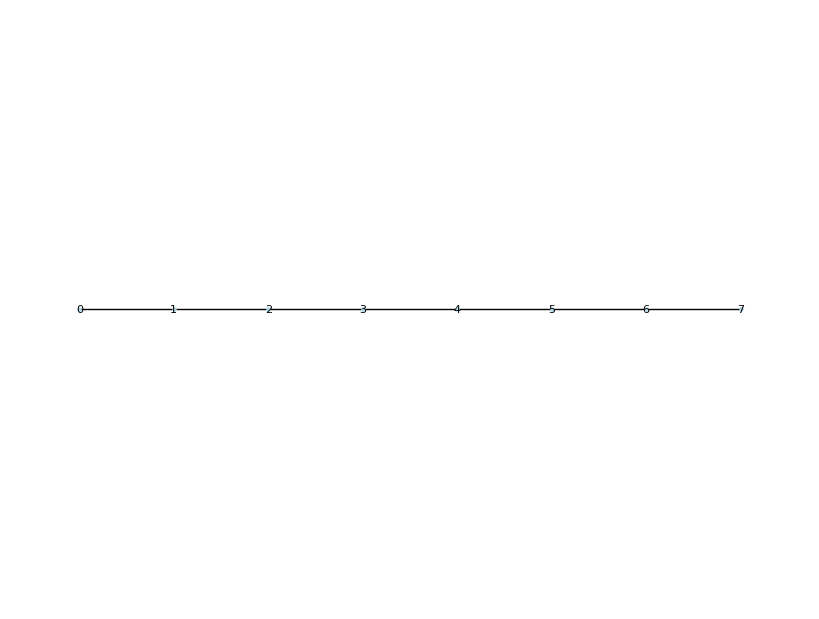

In [17]:
chain_graph = read_nxgraph(chain_file)
draw_graph(chain_graph, 8, 8)

In [18]:
gurobi_obj, gurobi_sol = gurobi_ising_solver(chain_graph)

Restricted license - for non-production use only - expires 2027-11-29
Set parameter TimeLimit to value 3600
Set parameter MIPGap to value 0
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (win64 - Windows 10.0 (19045.2))

CPU model: AMD Ryzen 7 5800H with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Non-default parameters:
TimeLimit  3600
MIPGap  0

Optimize a model with 0 rows, 8 columns and 0 nonzeros (Min)
Model fingerprint: 0x2dc2c2e4
Model has 8 linear objective coefficients and an objective constant of -2.3651481425574987e+00
Model has 7 quadratic objective terms
Variable types: 0 continuous, 8 integer (8 binary)
Coefficient statistics:
  Matrix range     [0e+00, 0e+00]
  Objective range  [4e-01, 2e+00]
  QObjective range [7e-01, 6e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [0e+00, 0e+00]
Found heuristic solution: objective -2.3651481
Found heuristic solution: objective -2.3651481
P

In [19]:
print("Minimum Energy State:", gurobi_obj)
print("Solution (spin configuration):", gurobi_sol)

Minimum Energy State: -2.3651481425575005
Solution (spin configuration): 11111111


## 2.2. Qiskit

In [20]:
paulis = build_paulis(chain_graph)
cost_hamiltonian = SparsePauliOp.from_sparse_list(paulis, 8)
print(cost_hamiltonian)

SparsePauliOp(['IIIIIIZZ', 'IIIIIZZI', 'IIIIZZII', 'IIIZZIII', 'IIZZIIII', 'IZZIIIII', 'ZZIIIIII'],
              coeffs=[-0.417022  +0.j, -0.72032449+0.j, -0.50011437+0.j, -0.30233257+0.j,
 -0.14675589+0.j, -0.09233859+0.j, -0.18626021+0.j])


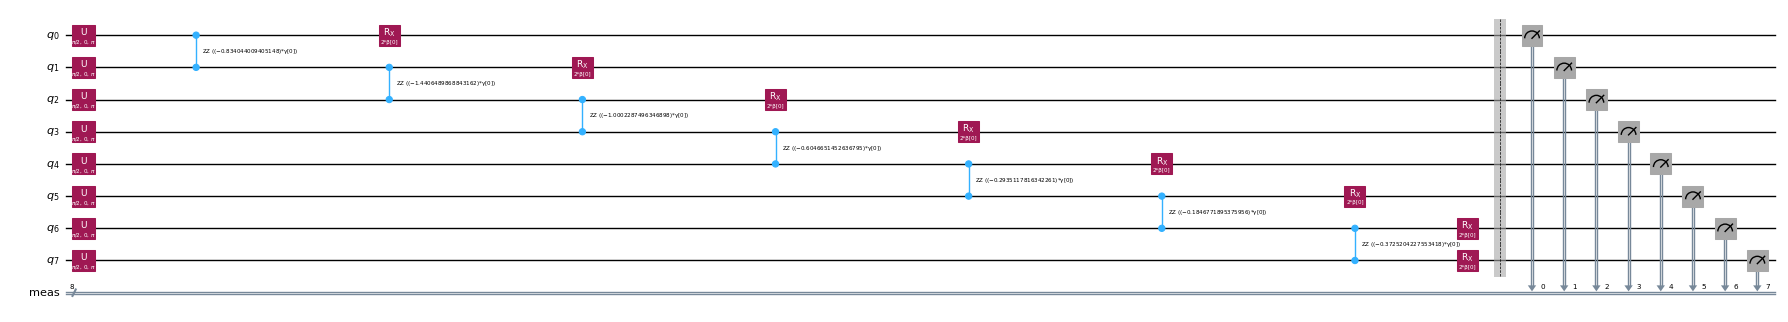

In [21]:
ansatz = build_ansatz(cost_hamiltonian, reps=1)
ansatz.decompose().decompose().draw(output="mpl", fold=False, idle_wires=False, scale=0.5)

In [22]:
candidate_circuit = pm.run(ansatz)
initial_gamma = 1.0
initial_beta = 0.5
init_params = [initial_beta, initial_gamma]

objective_func_vals = []
with Session(backend=qpu) as session:
    estimator = Estimator(mode=session)

    estimator.options.default_shots = 1000

    estimator.options.dynamical_decoupling.enable = True
    estimator.options.dynamical_decoupling.sequence_type = "XY4"
    estimator.options.twirling.enable_gates = True
    estimator.options.twirling.num_randomizations = "auto"

    estimator.options.resilience.zne_mitigation = True
    estimator.options.resilience.zne.noise_factors = (1, 3, 5)
    estimator.options.resilience.zne.extrapolator = ("exponential", "linear")

    optimizer = SPSA(maxiter=100)
    
    result = optimizer.minimize(
        fun=spsa_cost_wrapper,
        x0=init_params
    )
    print(result)

{   'fun': array(-1.10303519),
    'jac': None,
    'nfev': 200,
    'nit': 100,
    'njev': None,
    'x': array([1.14659044, 0.86275802])}


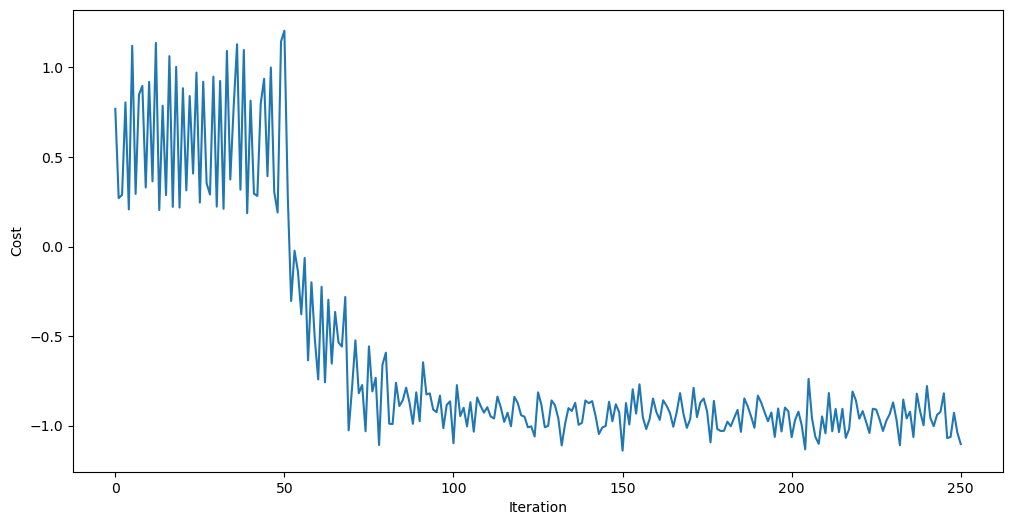

In [23]:
plt.figure(figsize=(12, 6))
plt.plot(objective_func_vals)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

In [24]:
optimized_circuit = candidate_circuit.assign_parameters(result.x)
sampler = Sampler(mode=qpu)

sampler.options.default_shots = 100000

# Set simple error suppression/mitigation options
sampler.options.dynamical_decoupling.enable = True
sampler.options.dynamical_decoupling.sequence_type = "XY4"
sampler.options.twirling.enable_gates = True
sampler.options.twirling.num_randomizations = "auto"

pub = (optimized_circuit)
job = sampler.run([pub], shots=int(1e5))
counts_int = job.result()[0].data.meas.get_int_counts()
counts_bin = job.result()[0].data.meas.get_counts()

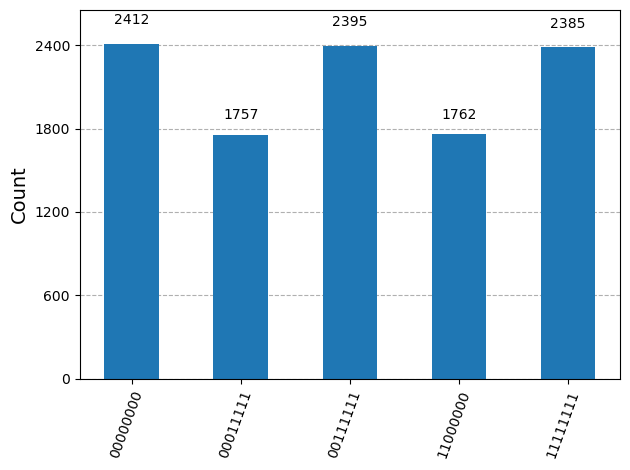

In [25]:
top_5 = dict(sorted(counts_bin.items(), key=lambda item: item[1], reverse=True)[:5])
plot_histogram(top_5)

In [26]:
most_frequent_string = max(counts_bin, key=counts_bin.get)
energy = calculate_energy(most_frequent_string[::-1], chain_graph)
print(f"Energy of {most_frequent_string[::-1]}: {energy}")

Energy of 00000000: -2.3651481425574987


In [27]:
print(f"Gurobi: {gurobi_obj}, {gurobi_sol}")
print(f"Qiskit: {energy}, {most_frequent_string[::-1]}")

Gurobi: -2.3651481425575005, 11111111
Qiskit: -2.3651481425574987, 00000000


# 3. 4x4 2D Lattice
## 3.1 Gurobi

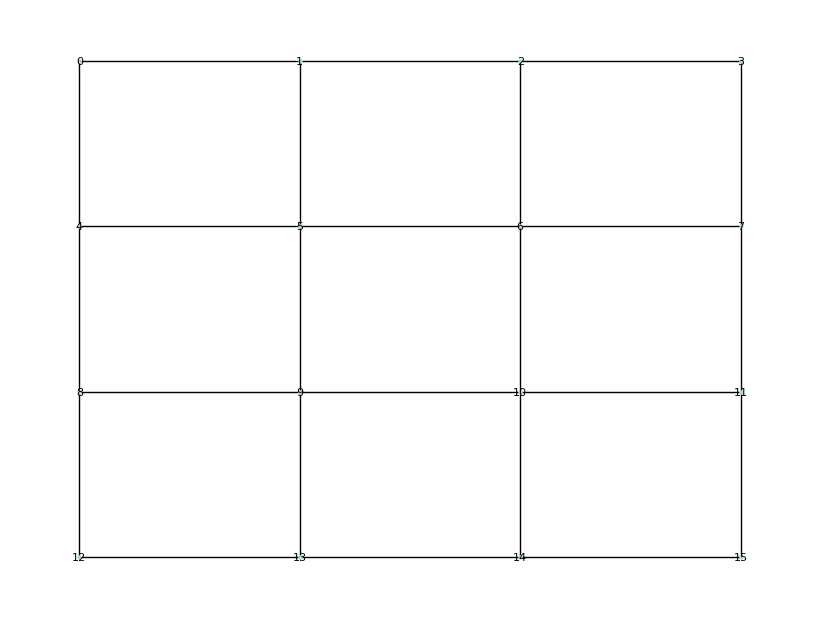

In [28]:
small_nearest_graph = read_nxgraph(small_nearest_file)
draw_graph(small_nearest_graph, 4, 4)

In [29]:
gurobi_obj, gurobi_sol = gurobi_ising_solver(small_nearest_graph)

Set parameter TimeLimit to value 3600
Set parameter MIPGap to value 0
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (win64 - Windows 10.0 (19045.2))

CPU model: AMD Ryzen 7 5800H with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Non-default parameters:
TimeLimit  3600
MIPGap  0

Optimize a model with 0 rows, 16 columns and 0 nonzeros (Min)
Model fingerprint: 0x4b5c5a5f
Model has 16 linear objective coefficients and an objective constant of -2.5307574172301228e-01
Model has 24 quadratic objective terms
Variable types: 0 continuous, 16 integer (16 binary)
Coefficient statistics:
  Matrix range     [0e+00, 0e+00]
  Objective range  [1e-01, 4e+00]
  QObjective range [6e-01, 8e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [0e+00, 0e+00]
Found heuristic solution: objective -0.2530757
Found heuristic solution: objective -0.2530757
Found heuristic solution: objective -10.9381498
Presolve removed 0

In [30]:
print("Minimum Energy State:", gurobi_obj)
print("Solution (spin configuration):", gurobi_sol)

Minimum Energy State: -10.93814981250091
Solution (spin configuration): 0111011011100100


## 3.2. Qiskit

In [31]:
paulis = build_paulis(small_nearest_graph)
cost_hamiltonian = SparsePauliOp.from_sparse_list(paulis, 16)
print(cost_hamiltonian)

SparsePauliOp(['IIIIIIIIIIIIIIZZ', 'IIIIIIIIIIIZIIIZ', 'IIIIIIIIIIIIIZZI', 'IIIIIIIIIIZIIIZI', 'IIIIIIIIIIIIZZII', 'IIIIIIIIIZIIIZII', 'IIIIIIIIZIIIZIII', 'IIIIIIIIIIZZIIII', 'IIIIIIIZIIIZIIII', 'IIIIIIIIIZZIIIII', 'IIIIIIZIIIZIIIII', 'IIIIIIIIZZIIIIII', 'IIIIIZIIIZIIIIII', 'IIIIZIIIZIIIIIII', 'IIIIIIZZIIIIIIII', 'IIIZIIIZIIIIIIII', 'IIIIIZZIIIIIIIII', 'IIZIIIZIIIIIIIII', 'IIIIZZIIIIIIIIII', 'IZIIIZIIIIIIIIII', 'ZIIIZIIIIIIIIIII', 'IIZZIIIIIIIIIIII', 'IZZIIIIIIIIIIIII', 'ZZIIIIIIIIIIIIII'],
              coeffs=[ 0.16595599+0.j, -0.44064899+0.j, -0.60148914+0.j, -0.93652315+0.j,
 -0.97772218+0.j, -0.49633131+0.j,  0.17188802+0.j,  0.99977125+0.j,
  0.39533485+0.j,  0.37315164+0.j, -0.38464523+0.j,  0.43911202+0.j,
 -0.57855866+0.j,  0.17164146+0.j,  0.70648822+0.j,  0.81532281+0.j,
 -0.7527783 +0.j, -0.78921333+0.j,  0.79354799+0.j,  0.10421295+0.j,
 -0.07179281+0.j,  0.62747958+0.j,  0.82991158+0.j, -0.81719101+0.j])


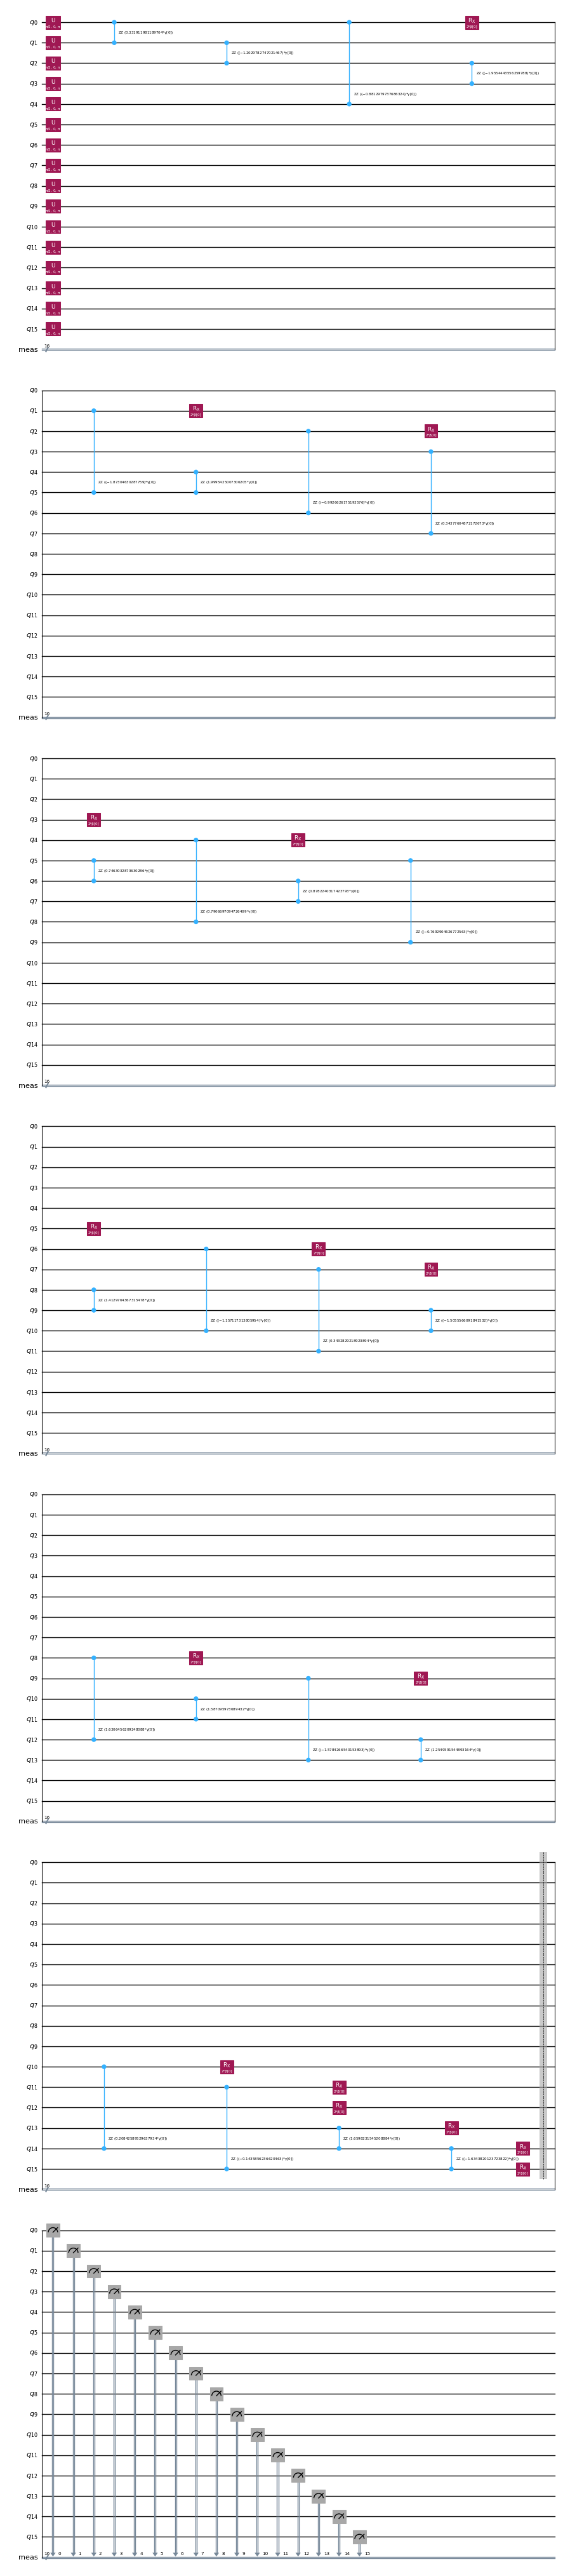

In [32]:
ansatz = build_ansatz(cost_hamiltonian, reps=1)
ansatz.decompose().decompose().draw(output="mpl", idle_wires=False, scale=0.5)

In [33]:
candidate_circuit = pm.run(ansatz)
initial_gamma = 1.0
initial_beta = 0.5
init_params = [initial_beta, initial_gamma]

objective_func_vals = []
with Session(backend=qpu) as session:
    estimator = Estimator(mode=session)

    estimator.options.default_shots = 1000

    estimator.options.dynamical_decoupling.enable = True
    estimator.options.dynamical_decoupling.sequence_type = "XY4"
    estimator.options.twirling.enable_gates = True
    estimator.options.twirling.num_randomizations = "auto"

    estimator.options.resilience.zne_mitigation = True
    estimator.options.resilience.zne.noise_factors = (1, 3, 5)
    estimator.options.resilience.zne.extrapolator = ("exponential", "linear")

    optimizer = SPSA(maxiter=100)
    
    result = optimizer.minimize(
        fun=spsa_cost_wrapper,
        x0=init_params
    )
    print(result)

{   'fun': array(-0.03652155),
    'jac': None,
    'nfev': 200,
    'nit': 100,
    'njev': None,
    'x': array([1.85680949, 3.00736788])}


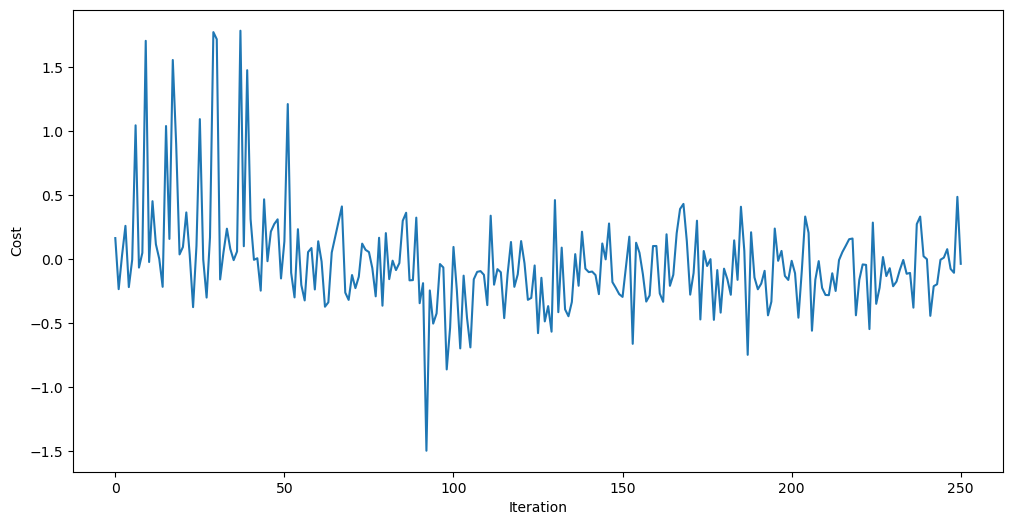

In [34]:
plt.figure(figsize=(12, 6))
plt.plot(objective_func_vals)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

In [35]:
optimized_circuit = candidate_circuit.assign_parameters(result.x)
sampler = Sampler(mode=qpu)

sampler.options.default_shots = 100000

# Set simple error suppression/mitigation options
sampler.options.dynamical_decoupling.enable = True
sampler.options.dynamical_decoupling.sequence_type = "XY4"
sampler.options.twirling.enable_gates = True
sampler.options.twirling.num_randomizations = "auto"

pub = (optimized_circuit)
job = sampler.run([pub], shots=int(1e5))
counts_int = job.result()[0].data.meas.get_int_counts()
counts_bin = job.result()[0].data.meas.get_counts()

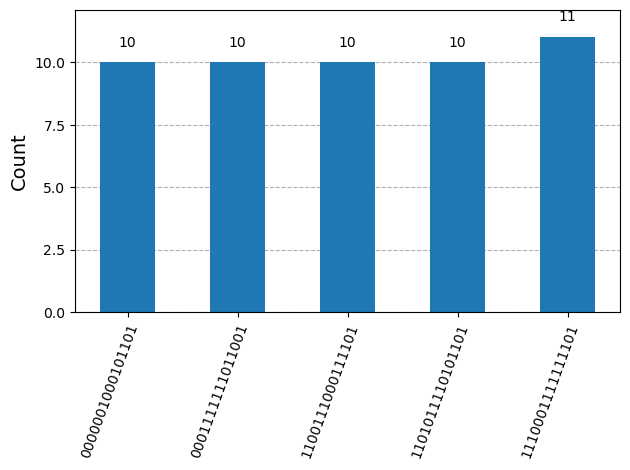

In [36]:
top_5 = dict(sorted(counts_bin.items(), key=lambda item: item[1], reverse=True)[:5])
plot_histogram(top_5)

In [37]:
most_frequent_string = max(counts_bin, key=counts_bin.get)
energy = calculate_energy(most_frequent_string[::-1], small_nearest_graph)
print(f"Energy of {most_frequent_string[::-1]}: {energy}")

Energy of 1011111111000111: 1.85998280871628


In [38]:
print(f"Gurobi: {gurobi_obj}, {gurobi_sol}")
print(f"Qiskit: {energy}, {most_frequent_string[::-1]}")

Gurobi: -10.93814981250091, 0111011011100100
Qiskit: 1.85998280871628, 1011111111000111


# 4. 10x10 2D Lattice

## 4.1 Gurobi

In [ ]:
nearest_neighbor_graph = read_nxgraph(nearest_neighbor_file)
draw_graph(nearest_neighbor_graph, 10, 10)

In [ ]:
gurobi_obj, gurobi_sol = gurobi_ising_solver(nearest_neighbor_graph)

In [ ]:
print("Minimum Energy State:", gurobi_obj)
print("Solution (spin configuration):", gurobi_sol)

## 4.2 Qiskit

In [ ]:
paulis = build_paulis(nearest_neighbor_graph)
cost_hamiltonian = SparsePauliOp.from_sparse_list(paulis, 100)
print(cost_hamiltonian)

In [ ]:
ansatz = build_ansatz(cost_hamiltonian, reps=1)
ansatz.decompose().decompose().draw(output="mpl", idle_wires=False, scale=1)

In [ ]:
candidate_circuit = pm.run(ansatz)
initial_gamma = 1.0
initial_beta = 0.5
init_params = [initial_beta, initial_gamma]

objective_func_vals = []
with Session(backend=qpu) as session:
    estimator = Estimator(mode=session)

    estimator.options.default_shots = 1000

    estimator.options.dynamical_decoupling.enable = True
    estimator.options.dynamical_decoupling.sequence_type = "XY4"
    estimator.options.twirling.enable_gates = True
    estimator.options.twirling.num_randomizations = "auto"

    estimator.options.resilience.zne_mitigation = True
    estimator.options.resilience.zne.noise_factors = (1, 3, 5)
    estimator.options.resilience.zne.extrapolator = ("exponential", "linear")

    result = minimize(
        cost_func,
        init_params,
        args=(candidate_circuit, cost_hamiltonian, estimator),
        method="COBYLA"
    )
    print(result)

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(objective_func_vals)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

In [ ]:
optimized_circuit = candidate_circuit.assign_parameters(result.x)
sampler = Sampler(mode=qpu)

sampler.options.default_shots = 100000

# Set simple error suppression/mitigation options
sampler.options.dynamical_decoupling.enable = True
sampler.options.dynamical_decoupling.sequence_type = "XY4"
sampler.options.twirling.enable_gates = True
sampler.options.twirling.num_randomizations = "auto"

pub = (optimized_circuit)
job = sampler.run([pub], shots=int(1e5))
counts_int = job.result()[0].data.meas.get_int_counts()
counts_bin = job.result()[0].data.meas.get_counts()

In [ ]:
top_5 = dict(sorted(counts_bin.items(), key=lambda item: item[1], reverse=True)[:10])
plot_histogram(top_5)

In [ ]:
most_frequent_string = max(counts_bin, key=counts_bin.get)
energy = calculate_energy(most_frequent_string[::-1], nearest_neighbor_graph)
print(f"Energy of {most_frequent_string[::-1]}: {energy}")

In [ ]:
print(f"Gurobi: {gurobi_obj}, {gurobi_sol}")
print(f"Qiskit: {energy}, {most_frequent_string[::-1]}")